# **New York City Crash Injury Prediction**
## **Summer 2026 Data Science Project**
### *By: Arvind Kakanavaram, Yudhiishbala Senthilkumar, Ethan Zhen*

## **Contributions**
* **Arvind Kakanavaram** worked on **B: Dataset Curation and Preprocessing**, **C: Data Exploration and Summary Statistics**, **F: Visualization, Result Analysis, Conclusion**, and **G: Final Tutorial Report Creation**. Arvind helped clean the NYC crash dataset, create the exploratory plots, and write the explanations that connect the results back to traffic safety.
* **Yudhiishbala Senthilkumar** worked on **A: Project Idea**, **B: Dataset Curation and Preprocessing**, **C: Data Exploration and Summary Statistics**, **F: Visualization, Result Analysis, Conclusion**, and **G: Final Tutorial Report Creation**. Yudhiishbala helped choose and refine the injury-risk prediction question, connect the NYC crash dataset to that question, and shape the preprocessing/EDA workflow around the course data science pipeline. Yudhiishbala also helped revise the final tutorial so the visualizations, model results, limitations, and conclusions clearly answered the project question in a readable student tutorial format.
* **Ethan Zhen** worked on **D: ML Algorithm Design/Development**, **E: ML Algorithm Training and Test Data Analysis**, **F: Visualization, Result Analysis, Conclusion**, and **G: Final Tutorial Report Creation**. Ethan helped design the Random Forest classification workflow, evaluate the model with train/test metrics, and interpret which crash characteristics were most useful for prediction.

This tutorial follows the data science pipeline we practiced in CMSC320: define a question, acquire and curate data, explore the data, use statistics to test patterns, train a machine learning model, visualize the results, and explain what the results mean.

# **Introduction**

Traffic collisions are a major public safety issue in New York City. A crash record is not just a row in a spreadsheet: it represents a real incident involving drivers, passengers, pedestrians, cyclists, and city infrastructure. For this project, we use the **Motor Vehicle Collisions - Crashes** dataset from [NYC Open Data](https://data.cityofnewyork.us/Public-Safety/Motor-Vehicle-Collisions-Crashes/h9gi-nx95/about_data). The dataset records police-reported crashes across NYC and includes information such as crash date, crash time, borough, location, contributing factors, vehicle types, and injury/fatality counts.

Our main question is:

> **Can we predict whether a reported NYC motor vehicle collision results in at least one injury, and which crash characteristics are most strongly associated with injury risk?**

This question matters because it moves beyond simply counting crashes. If we can identify patterns associated with injury risk, then city planners, transportation officials, and the public can better understand which crash conditions are connected to more serious outcomes. We are not claiming that our model proves causation, but we can use data exploration, hypothesis testing, and machine learning to identify useful associations.

The project uses a classification approach because the outcome is binary: a crash either has at least one injured person or it does not. Along the way, we will also use summary statistics, correlation, a chi-square hypothesis test, and visualizations to understand the dataset before building the model.

# **Data Curation**

The data source is the NYC Open Data page for [Motor Vehicle Collisions - Crashes](https://data.cityofnewyork.us/Public-Safety/Motor-Vehicle-Collisions-Crashes/h9gi-nx95/about_data). NYC Open Data is powered by Socrata, which lets us download data directly into a pandas DataFrame. To keep this tutorial reproducible and reasonable to run in a browser or notebook environment, we use a fixed query:

* only crashes on or before **June 15, 2026**, matching the project dataset cutoff;
* a deterministic row order;
* a maximum number of rows for runtime.

This is still a large real-world sample, but it avoids depending on newly added records after our project cutoff date. In this section, we import the data, parse dates and numeric columns, clean missing values, and create the target variable `has_injury`.

Helpful references:
* [pandas DataFrame documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html)
* [pandas `to_datetime`](https://pandas.pydata.org/docs/reference/api/pandas.to_datetime.html)
* [NYC Open Data API documentation](https://dev.socrata.com/foundry/data.cityofnewyork.us/h9gi-nx95)

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split

sns.set_theme(style="whitegrid")
RANDOM_STATE = 320
DATA_LIMIT = 120_000
DATA_CUTOFF = "2026-06-15"

In [2]:
# Data acquisition
# Socrata's CSV endpoint is convenient because pandas can read it directly.
# We order by crash date and collision ID so the sample is recent, reproducible, and fixed by the cutoff.
base_url = "https://data.cityofnewyork.us/resource/h9gi-nx95.csv"
query = (
    f"?$limit={DATA_LIMIT}"
    f"&$order=crash_date DESC, collision_id"
    f"&$where=crash_date <= '{DATA_CUTOFF}T23:59:59'"
)
url = base_url + query.replace(" ", "%20")

crashes_df = pd.read_csv(url, low_memory=False)

print(f"Loaded {crashes_df.shape[0]:,} crash records and {crashes_df.shape[1]} columns.")
display(crashes_df.head())

Loaded 120,000 crash records and 29 columns.


,crash_date,crash_time,borough,zip_code,latitude,longitude,location,on_street_name,off_street_name,cross_street_name,number_of_persons_injured,number_of_persons_killed,number_of_pedestrians_injured,number_of_pedestrians_killed,number_of_cyclist_injured,number_of_cyclist_killed,number_of_motorist_injured,number_of_motorist_killed,contributing_factor_vehicle_1,contributing_factor_vehicle_2,contributing_factor_vehicle_3,contributing_factor_vehicle_4,contributing_factor_vehicle_5,collision_id,vehicle_type_code1,vehicle_type_code2,vehicle_type_code_3,vehicle_type_code_4,vehicle_type_code_5
0,2026-06-11T00:00:00.000,1:30,QUEENS,11434.0,40.667915,-73.77522,"\n, \n(40.667915, -73.77522)",N CONDUIT AVE,160 ST,NaN,0,NaN,0,0,0,0,0,0,Driver Inattention/Distraction,Unspecified,NaN,NaN,NaN,4905680,4 dr sedan,NaN,NaN,NaN,NaN
1,2026-06-11T00:00:00.000,1:55,NaN,NaN,40.625410,-74.14939,"\n, \n(40.62541, -74.14939)",NaN,NaN,1815 FOREST AVE,1,NaN,1,0,0,0,0,0,Backing Unsafely,NaN,NaN,NaN,NaN,4905694,Sedan,NaN,NaN,NaN,NaN
2,2026-06-11T00:00:00.000,3:50,MANHATTAN,10002.0,40.709805,-73.99191,"\n, \n(40.709805, -73.99191)",SOUTH ST,PIKE SLIP,NaN,0,NaN,0,0,0,0,0,0,Driver Inattention/Distraction,NaN,NaN,NaN,NaN,4905704,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN
3,2026-06-11T00:00:00.000,0:32,BROOKLYN,11217.0,40.681350,-73.97526,"\n, \n(40.68135, -73.97526)",NaN,NaN,227 FLATBUSH AVE,1,NaN,0,0,0,0,1,0,Unsafe Speed,Unspecified,Unspecified,NaN,NaN,4905713,Sedan,Motorcycle,NaN,NaN,NaN
4,2026-06-11T00:00:00.000,6:30,STATEN ISLAND,10306.0,40.572820,-74.13628,"\n, \n(40.57282, -74.13628)",NaN,NaN,3468 RICHMOND RD,0,NaN,0,0,0,0,0,0,Passing or Lane Usage Improper,Unspecified,NaN,NaN,NaN,4905715,4 dr sedan,School Bus,NaN,NaN,NaN


In [3]:
# Data preprocessing
# The raw API column names are lowercase with underscores. We keep them because they are easy to use in code.
date_cols = ["crash_date"]
time_cols = ["crash_time"]

numeric_cols = [
    "number_of_persons_injured",
    "number_of_persons_killed",
    "number_of_pedestrians_injured",
    "number_of_pedestrians_killed",
    "number_of_cyclist_injured",
    "number_of_cyclist_killed",
    "number_of_motorist_injured",
    "number_of_motorist_killed",
    "latitude",
    "longitude",
]

for col in date_cols:
    crashes_df[col] = pd.to_datetime(crashes_df[col], errors="coerce")

for col in time_cols:
    crashes_df[col] = pd.to_datetime(crashes_df[col], format="%H:%M", errors="coerce")

for col in numeric_cols:
    if col in crashes_df.columns:
        crashes_df[col] = pd.to_numeric(crashes_df[col], errors="coerce")

# Target variable: 1 if at least one person was injured, 0 otherwise.
crashes_df["has_injury"] = (crashes_df["number_of_persons_injured"].fillna(0) > 0).astype(int)

# A few time-based features make the model more useful than raw timestamps.
crashes_df["crash_hour"] = crashes_df["crash_time"].dt.hour
crashes_df["crash_month"] = crashes_df["crash_date"].dt.month
crashes_df["crash_dayofweek"] = crashes_df["crash_date"].dt.dayofweek
crashes_df["is_weekend"] = crashes_df["crash_dayofweek"].isin([5, 6]).astype(int)

print("Data types after parsing:")
display(crashes_df.dtypes.to_frame("dtype").head(20))

print("Target distribution:")
display(crashes_df["has_injury"].value_counts(normalize=True).rename("proportion").to_frame())

Data types after parsing:
Target distribution:


,dtype
crash_date,datetime64[ns]
crash_time,datetime64[ns]
borough,object
zip_code,float64
latitude,float64
longitude,float64
location,object
on_street_name,object
off_street_name,object
cross_street_name,object


,proportion
has_injury,
0,0.5694
1,0.4306


# **Exploratory Data Analysis**

Before choosing a machine learning model, we need to understand the dataset. This follows the EDA workflow from class: inspect the structure, summarize important variables, look for relationships, test a hypothesis, and identify unusual values. We focus on three questions:

1. How are different injury/fatality counts related?
2. Do injury rates differ by borough?
3. What does the distribution of injury counts look like?

## **Analysis 1: Correlations Between Injury Counts**

A correlation matrix helps us see whether numeric injury variables move together. Correlation does not prove causation, but it is a useful first pass for understanding relationships between injury categories.

Reference: [correlation matrix overview](https://www.displayr.com/what-is-a-correlation-matrix/) and [seaborn heatmap](https://seaborn.pydata.org/generated/seaborn.heatmap.html).

,number_of_persons_injured,number_of_persons_killed,number_of_pedestrians_injured,number_of_pedestrians_killed,number_of_cyclist_injured,number_of_cyclist_killed,number_of_motorist_injured,number_of_motorist_killed
number_of_persons_injured,1.000,-0.004,0.215,-0.004,0.144,-0.006,0.884,0.005
number_of_persons_killed,-0.004,1.000,-0.004,0.713,-0.009,0.317,0.001,0.615
number_of_pedestrians_injured,0.215,-0.004,1.000,0.006,-0.073,-0.002,-0.142,-0.009
number_of_pedestrians_killed,-0.004,0.713,0.006,1.000,-0.007,0.012,-0.004,0.013
number_of_cyclist_injured,0.144,-0.009,-0.073,-0.007,1.000,-0.000,-0.113,-0.007
number_of_cyclist_killed,-0.006,0.317,-0.002,0.012,-0.000,1.000,-0.005,-0.000
number_of_motorist_injured,0.884,0.001,-0.142,-0.004,-0.113,-0.005,1.000,0.011
number_of_motorist_killed,0.005,0.615,-0.009,0.013,-0.007,-0.000,0.011,1.000


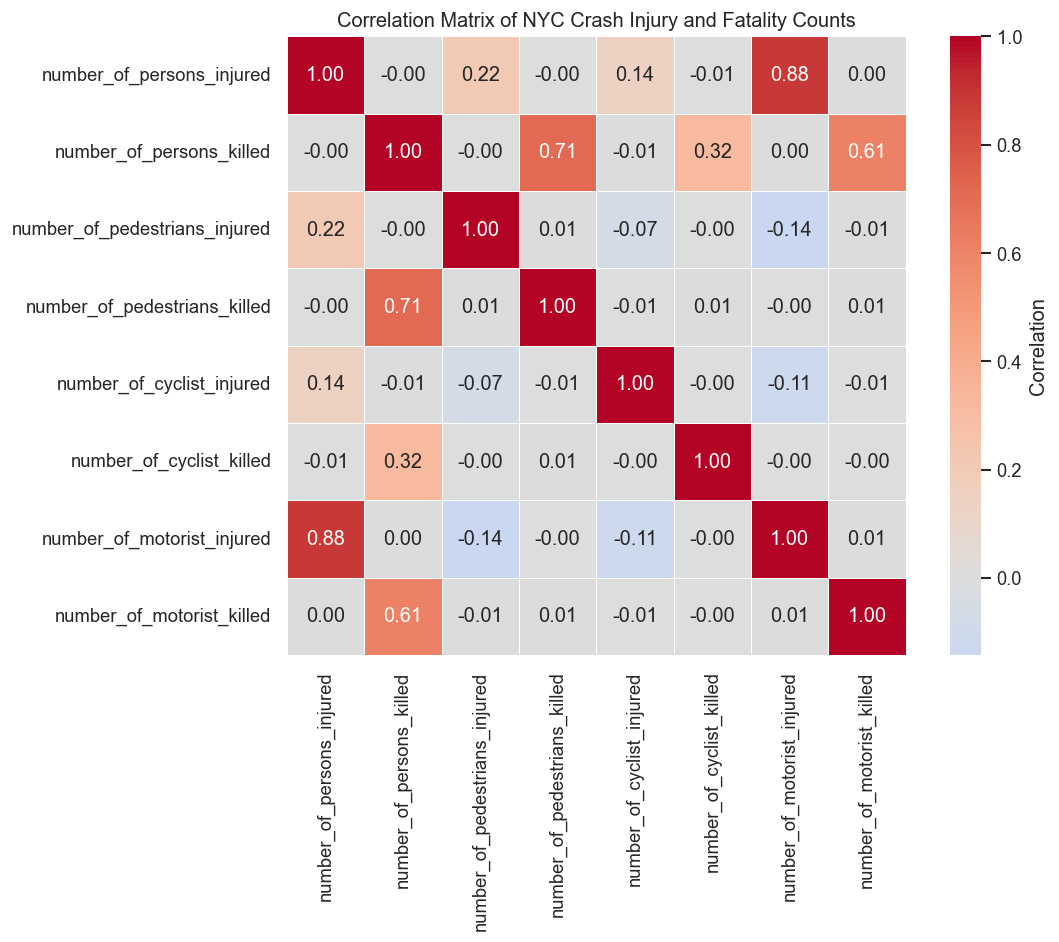

In [4]:
injury_cols = [
    "number_of_persons_injured",
    "number_of_persons_killed",
    "number_of_pedestrians_injured",
    "number_of_pedestrians_killed",
    "number_of_cyclist_injured",
    "number_of_cyclist_killed",
    "number_of_motorist_injured",
    "number_of_motorist_killed",
]

corr_matrix = crashes_df[injury_cols].corr()
display(corr_matrix.round(3))

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Correlation"},
)
plt.title("Correlation Matrix of NYC Crash Injury and Fatality Counts")
plt.tight_layout()
plt.show()

**Conclusion from Analysis 1.** Total persons injured is most strongly connected with motorist injuries, which makes sense because many crash records involve drivers or passengers. Fatality variables are much rarer, so their correlations are harder to interpret. This tells us that injury risk is not evenly distributed across all road-user types.

## **Analysis 2: Hypothesis Testing - Injury Rates by Borough**

Next we test whether injury outcome and borough are independent. Since both variables are categorical, we use a **chi-square test of independence**, which was one of the hypothesis-testing tools covered in class.

* **Null hypothesis:** borough and injury outcome are independent.
* **Alternative hypothesis:** borough and injury outcome are associated.
* **Significance level:** alpha = 0.05.

References: [chi-square test](https://www.jmp.com/en/statistics-knowledge-portal/linear-models/chi-square-test) and [contingency tables](https://statisticsbyjim.com/basics/contingency-table/).

Chi-square statistic: 112.610
p-value: 0.000000
Degrees of freedom: 4
Decision: Reject H0


,injuries,total_crashes,injury_rate
borough,,,
BROOKLYN,14541,33396,43.54%
BRONX,6289,14545,43.24%
MANHATTAN,7505,18246,41.13%
QUEENS,10062,24627,40.86%
STATEN ISLAND,1390,3835,36.25%


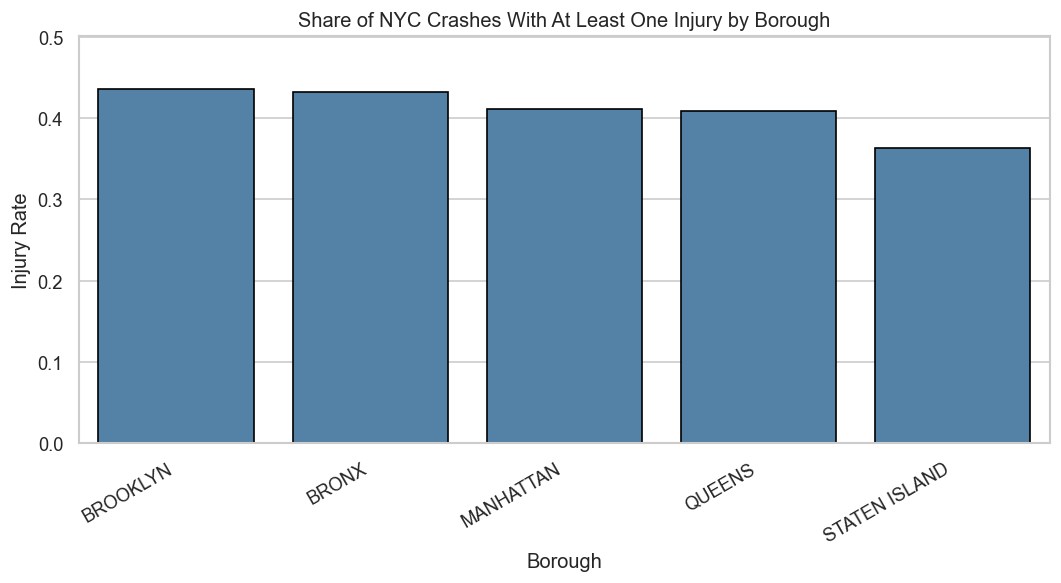

In [5]:
borough_data = crashes_df[crashes_df["borough"].notna()].copy()

borough_summary = (
    borough_data.groupby("borough")
    .agg(
        injuries=("has_injury", "sum"),
        total_crashes=("has_injury", "count"),
        injury_rate=("has_injury", "mean"),
    )
    .sort_values("injury_rate", ascending=False)
)

display(borough_summary.style.format({"injury_rate": "{:.2%}"}))

contingency_table = pd.crosstab(borough_data["borough"], borough_data["has_injury"])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square statistic: {chi2:.3f}")
print(f"p-value: {p_value:.6f}")
print(f"Degrees of freedom: {dof}")
print("Decision:", "Reject H0" if p_value < 0.05 else "Fail to reject H0")

plt.figure(figsize=(9, 5))
sns.barplot(
    data=borough_summary.reset_index(),
    x="borough",
    y="injury_rate",
    color="steelblue",
    edgecolor="black",
)
plt.title("Share of NYC Crashes With At Least One Injury by Borough")
plt.xlabel("Borough")
plt.ylabel("Injury Rate")
plt.ylim(0, max(borough_summary["injury_rate"]) * 1.15)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

**Conclusion from Analysis 2.** If the p-value is below 0.05, we reject the null hypothesis and conclude that injury outcome is associated with borough in this sample. This does not mean that borough alone causes injuries, but it suggests that location-related factors such as road design, traffic volume, speed, and travel behavior may matter.

## **Analysis 3: Distribution Analysis and Outlier Detection**

The number of people injured per crash is a count variable. Many crashes have zero injuries, while a small number of crashes involve multiple injuries. This kind of right-skewed distribution is important because it affects both summary statistics and model design.

Reference: [IQR rule for outliers](https://www.khanacademy.org/math/statistics-probability/summarizing-quantitative-data/box-whisker-plots/a/identifying-outliers-iqr-rule).

Q1: 0.00
Q3: 1.00
IQR: 1.00
Outlier bounds: [-1.50, 2.50]
Outliers: 3,870 crashes (3.23%)


,number_of_persons_injured
count,120000.000000
mean,0.576283
std,0.850061
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,21.000000


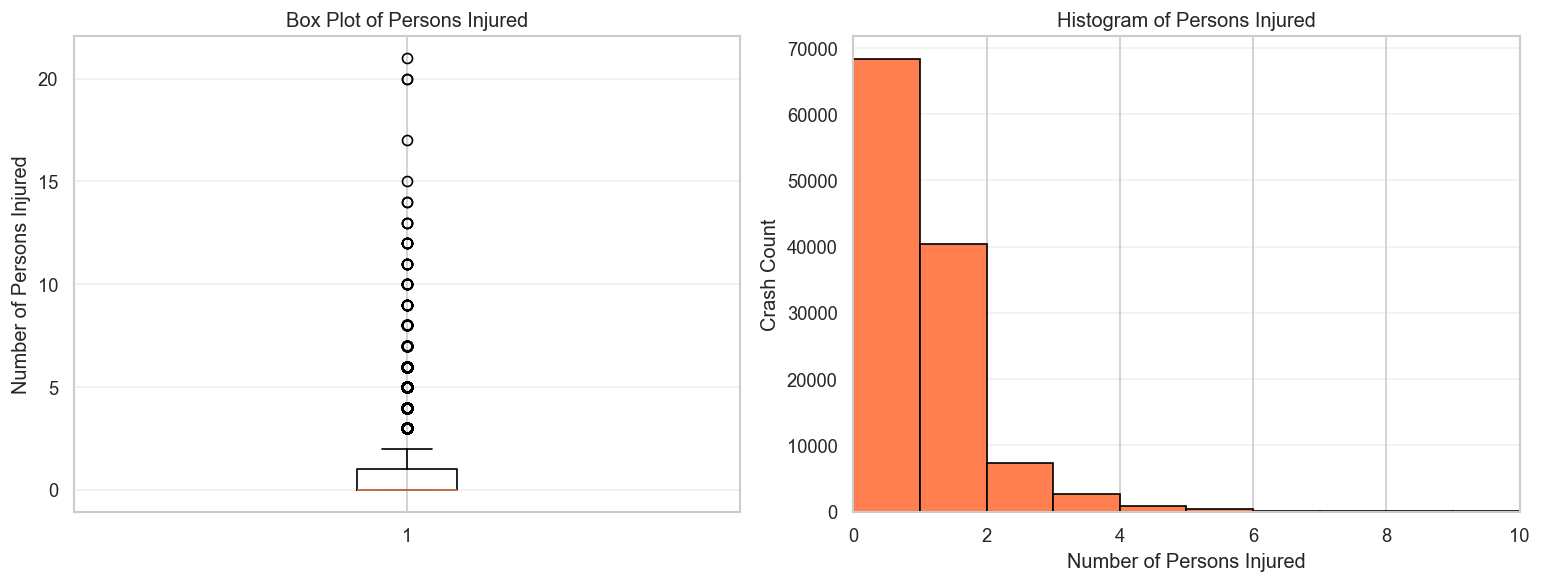

In [6]:
injury_distribution = crashes_df["number_of_persons_injured"].dropna()

summary_stats = injury_distribution.describe().to_frame("number_of_persons_injured")
display(summary_stats)

Q1 = injury_distribution.quantile(0.25)
Q3 = injury_distribution.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = injury_distribution[(injury_distribution < lower_bound) | (injury_distribution > upper_bound)]

print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Outlier bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Outliers: {len(outliers):,} crashes ({len(outliers) / len(injury_distribution):.2%})")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].boxplot(injury_distribution, vert=True)
axes[0].set_title("Box Plot of Persons Injured")
axes[0].set_ylabel("Number of Persons Injured")
axes[0].grid(axis="y", alpha=0.3)

axes[1].hist(injury_distribution, bins=range(0, int(injury_distribution.max()) + 2), color="coral", edgecolor="black")
axes[1].set_title("Histogram of Persons Injured")
axes[1].set_xlabel("Number of Persons Injured")
axes[1].set_ylabel("Crash Count")
axes[1].set_xlim(0, min(10, injury_distribution.max()))
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

**Conclusion from Analysis 3.** The distribution is strongly right-skewed: most crashes have no injuries, and a smaller share have one or more injuries. Since the target is imbalanced, accuracy alone is not enough for the machine learning section. We should also inspect precision, recall, F1 score, and the confusion matrix.

## **EDA Findings - Summary**

The exploratory analysis gives us three important takeaways:

1. Injury variables are related, but different road-user groups do not all behave the same way.
2. The chi-square test suggests that injury rates differ by borough, so location should be considered in the model.
3. Injury outcomes are imbalanced because most crashes have no injuries.

Based on these findings, a classification model is appropriate because our main outcome is whether a crash has at least one injury.

# **Primary Analysis**

Our primary analysis uses a **Random Forest classifier** to predict `has_injury`. Random Forest is a good choice for this project because:

* it works for classification problems;
* it can handle nonlinear relationships;
* it can use a mix of numeric variables and one-hot encoded categorical variables;
* it gives feature importances, which helps answer the second part of our research question.

This section follows the machine learning process from class: choose features, split train/test data, preprocess features, train a model, evaluate it on unseen test data, and interpret the results. To keep the workflow close to what we practiced in class, we use pandas cleaning, `pd.get_dummies()` for one-hot encoding, and then align the train/test columns before fitting the model.

References:
* [scikit-learn RandomForestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)
* [train/test split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)
* [one-hot encoding](https://developers.google.com/machine-learning/crash-course/categorical-data/one-hot-encoding)
* [classification report](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html)

In [7]:
# Feature engineering for machine learning.
# We intentionally do not use the injury/fatality count columns as inputs because those directly define the target.
feature_cols = [
    "borough",
    "zip_code",
    "latitude",
    "longitude",
    "crash_hour",
    "crash_month",
    "crash_dayofweek",
    "is_weekend",
    "contributing_factor_vehicle_1",
    "contributing_factor_vehicle_2",
    "vehicle_type_code1",
    "vehicle_type_code2",
]

categorical_features = [
    "borough",
    "zip_code",
    "contributing_factor_vehicle_1",
    "contributing_factor_vehicle_2",
    "vehicle_type_code1",
    "vehicle_type_code2",
]

numeric_features = [
    "latitude",
    "longitude",
    "crash_hour",
    "crash_month",
    "crash_dayofweek",
    "is_weekend",
]

model_df = crashes_df[feature_cols + ["has_injury"]].copy()
X = model_df[feature_cols]
y = model_df["has_injury"]

print(f"Modeling rows: {len(model_df):,}")
print(f"Positive class rate: {y.mean():.2%}")

Modeling rows: 120,000
Positive class rate: 43.06%


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

X_train_clean = X_train.copy()
X_test_clean = X_test.copy()

# Fill missing numeric values using the training-set median.
for col in numeric_features:
    train_median = X_train_clean[col].median()
    X_train_clean[col] = X_train_clean[col].fillna(train_median)
    X_test_clean[col] = X_test_clean[col].fillna(train_median)

# Fill missing categories and group rare categories into "Other".
# This keeps the dummy-variable table readable and avoids thousands of tiny categories.
top_categories = {}
for col in categorical_features:
    X_train_clean[col] = X_train_clean[col].fillna("Unknown").astype(str)
    X_test_clean[col] = X_test_clean[col].fillna("Unknown").astype(str)

    top_values = X_train_clean[col].value_counts().head(20).index
    top_categories[col] = top_values

    X_train_clean[col] = X_train_clean[col].where(X_train_clean[col].isin(top_values), "Other")
    X_test_clean[col] = X_test_clean[col].where(X_test_clean[col].isin(top_values), "Other")

# One-hot encode the categorical columns using pandas, just like the feature engineering lecture.
X_train_encoded = pd.get_dummies(X_train_clean, columns=categorical_features)
X_test_encoded = pd.get_dummies(X_test_clean, columns=categorical_features)

# The test set may not contain every category seen in training, so we align the columns.
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

baseline_accuracy = max(y_test.mean(), 1 - y_test.mean())
print(f"Training shape after one-hot encoding: {X_train_encoded.shape}")
print(f"Test shape after one-hot encoding: {X_test_encoded.shape}")
print(f"Baseline accuracy from always predicting the majority class: {baseline_accuracy:.4f}")

Training shape after one-hot encoding: (96000, 117)
Test shape after one-hot encoding: (24000, 117)
Baseline accuracy from always predicting the majority class: 0.5694


In [9]:
# Cross-validation on the training set gives a more stable estimate than one split alone.
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=18,
    min_samples_leaf=20,
    random_state=RANDOM_STATE,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(rf_model, X_train_encoded, y_train, cv=cv, scoring="f1")

print(f"5-fold cross-validation F1 scores: {np.round(cv_scores, 4)}")
print(f"Mean CV F1: {cv_scores.mean():.4f}")
print(f"Standard deviation: {cv_scores.std():.4f}")

5-fold cross-validation F1 scores: [0.5913 0.6057 0.593  0.5939 0.5924]
Mean CV F1: 0.5953
Standard deviation: 0.0053


In [10]:
# Train the final model and evaluate it on the held-out test set.
rf_model.fit(X_train_encoded, y_train)
y_pred = rf_model.predict(X_test_encoded)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

metrics_df = pd.DataFrame(
    {
        "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
        "Score": [accuracy, precision, recall, f1],
    }
)

display(metrics_df.style.format({"Score": "{:.3f}"}))
print(classification_report(y_test, y_pred, target_names=["No Injury", "Injury"]))

              precision    recall  f1-score   support

   No Injury       0.70      0.87      0.77     13666
      Injury       0.75      0.49      0.59     10334

    accuracy                           0.71     24000
   macro avg       0.72      0.68      0.68     24000
weighted avg       0.72      0.71      0.70     24000



,Metric,Score
0,Accuracy,0.710
1,Precision,0.747
2,Recall,0.493
3,F1 Score,0.594


**Primary analysis interpretation.** The baseline accuracy is important because most crashes do not have injuries. If our model only had high accuracy but poor recall for injury crashes, it would not be very useful. For this project, recall and F1 score matter because we care about identifying injury-risk crashes, not just predicting the majority class.

# **Visualization**

The final deliverable requires at least one visualization based on the primary analysis. We include two:

1. a confusion matrix, which shows correct and incorrect classifications;
2. a feature-importance plot, which helps explain which crash characteristics were most useful to the Random Forest model.

Reference: [scikit-learn confusion matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html).

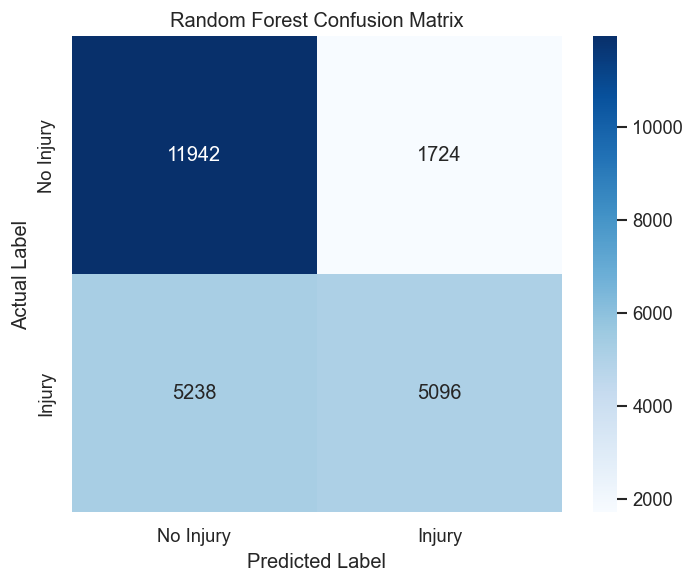

In [11]:
conf_mat = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    conf_mat,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Injury", "Injury"],
    yticklabels=["No Injury", "Injury"],
)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

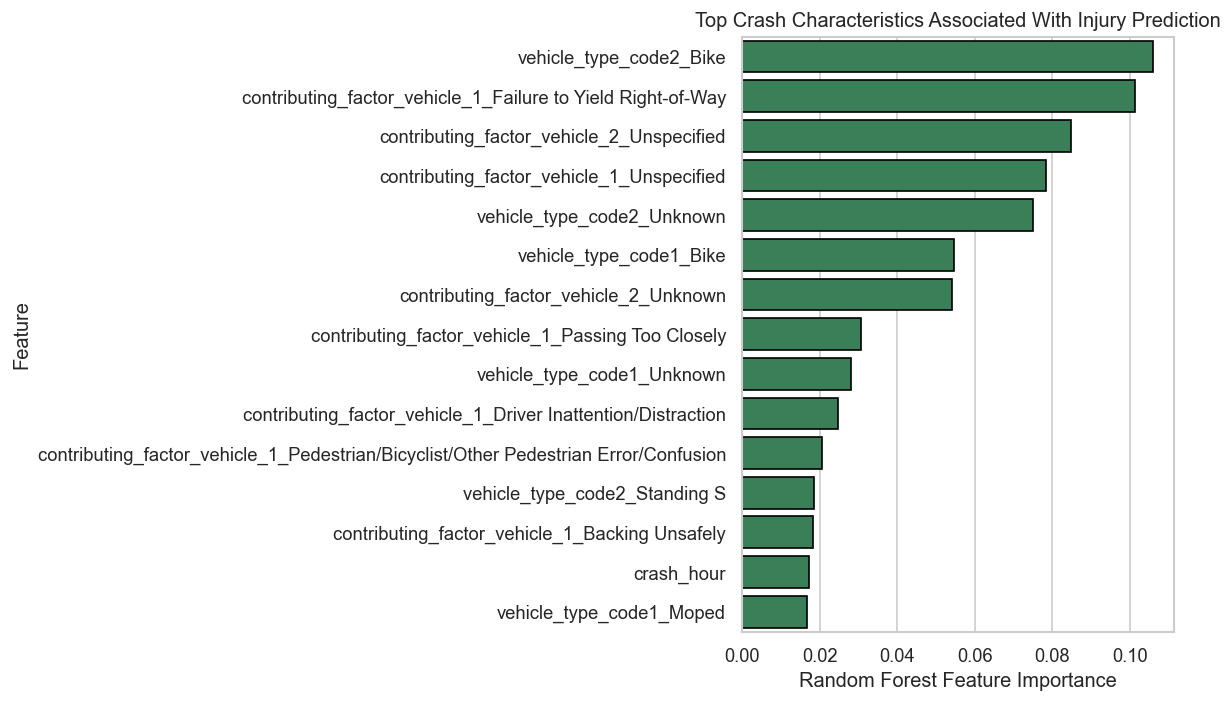

,feature,importance
99,vehicle_type_code2_Bike,0.105988
38,contributing_factor_vehicle_1_Failure to Yield...,0.101339
73,contributing_factor_vehicle_2_Unspecified,0.084730
52,contributing_factor_vehicle_1_Unspecified,0.078490
115,vehicle_type_code2_Unknown,0.075137
78,vehicle_type_code1_Bike,0.054664
70,contributing_factor_vehicle_2_Unknown,0.054141
42,contributing_factor_vehicle_1_Passing Too Closely,0.030805
94,vehicle_type_code1_Unknown,0.028025
36,contributing_factor_vehicle_1_Driver Inattenti...,0.024676


In [12]:
# Feature importances show which encoded columns the Random Forest used most often.
feature_importance_df = (
    pd.DataFrame({"feature": X_train_encoded.columns, "importance": rf_model.feature_importances_})
    .sort_values("importance", ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance_df,
    x="importance",
    y="feature",
    color="seagreen",
    edgecolor="black",
)
plt.title("Top Crash Characteristics Associated With Injury Prediction")
plt.xlabel("Random Forest Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

display(feature_importance_df)

**Visualization interpretation.** The confusion matrix shows where the model is succeeding and where it is making mistakes. The feature-importance chart shows which variables the Random Forest used most often to split crashes into injury and non-injury predictions. These importances are associations inside the model, not proof that a feature directly causes injuries.

# **Insights and Conclusions**

This project asked whether we can predict whether a reported NYC crash results in at least one injury and which crash characteristics are most associated with injury risk.

Overall, the answer is **partly yes**. The model can learn useful patterns from crash location, time, vehicle type, and contributing-factor variables, but the problem is challenging because injury crashes are less common than non-injury crashes. That is why we evaluated the model with precision, recall, F1 score, and a confusion matrix instead of relying only on accuracy.

The EDA showed that:

* most crashes have zero reported injuries, so the target variable is imbalanced;
* injury rates differ across boroughs in the sample, and the chi-square test suggests borough and injury outcome are associated;
* total injury counts are most strongly related to motorist injuries, while pedestrian and cyclist injuries represent smaller but important parts of the dataset.

The Random Forest model helped us move from exploration to prediction. Its feature importances give a practical way to discuss which crash characteristics are most associated with predicted injury risk. The strongest features should be interpreted as signals the model found useful, not as causal proof. For example, location and contributing-factor variables may reflect deeper causes such as traffic density, road design, speed, visibility, or reporting patterns.

There are also limitations. The dataset only includes reported crashes, so unreported incidents are missing. Some fields have missing values, especially location and secondary vehicle/contributing-factor columns. The model also uses a fixed sample from a very large dataset to keep the tutorial reproducible. Future work could compare multiple models, tune hyperparameters more carefully, include weather or traffic-volume data, and study pedestrian/cyclist injury risk separately.

After this analysis, an uninformed reader should understand that NYC crash injury risk is not random: it varies with geography, crash context, vehicle information, and reported contributing factors. A reader already familiar with traffic safety should still learn how these patterns can be explored through the full data science pipeline: data curation, EDA, hypothesis testing, machine learning, visualization, and careful interpretation.

# **The End**

Thank you for reading our CMSC320 final project tutorial.